**Task 1** — Data Loading & Exploration

- Load the CSV file using Pandas

In [146]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

- Display the first 10 rows

In [147]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


- Check how many rows and columns are there

In [148]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1470, 35)


- Identify the target column (Attrition — Yes/No)

In [149]:
print(df["Attrition"].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64


- Count how many employees left vs stayed and calculate the attrition rate as a percentage

In [150]:
attrition_rate = (df["Attrition"] == "Yes").mean() * 100

print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


- Identify how many columns are numeric vs categorical

In [151]:
numeric = df.select_dtypes(include=np.number).columns

categorical = df.select_dtypes(include="object").columns

print("Numeric Columns:", len(numeric))
print("Categorical Columns:", len(categorical))

Numeric Columns: 26
Categorical Columns: 9


**Observation**
- The dataset is imbalanced because only about 16% of employees left the company, while around 84% stayed. This means the machine learning models should handle class imbalance to avoid being biased toward the majority class.

**Task 2** — Data Cleaning & Preprocessing

- Check for missing/null values and handle them

In [152]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [153]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


- Drop columns that add no value to prediction (e.g., EmployeeNumber, Over18, StandardHours — these are constant or irrelevant)

In [154]:
df.drop(
    columns=[
        "EmployeeNumber",
        "Over18",
        "StandardHours",
        "EmployeeCount"
    ],
    inplace=True
)

In [155]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

- Convert the target column Attrition from Yes/No to 1/0

In [156]:
df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

In [157]:
df["Attrition"].value_counts()

,count
Attrition,
0,1233
1,237


In [158]:
#Separating Features and Target
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

- Encode all remaining categorical columns using One-Hot Encoding (e.g., Department, JobRole, MaritalStatus, BusinessTravel)


In [159]:
categorical_cols = X.select_dtypes(include="object").columns

print(categorical_cols)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')


In [160]:
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

In [161]:
print(X.shape)

(1470, 44)


- Scale numeric features using StandardScaler

In [162]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [163]:
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

In [164]:
print(X_scaled.head())

        Age  DailyRate  DistanceFromHome  Education  EnvironmentSatisfaction  \
0  0.446350   0.742527         -1.010909  -0.891688                -0.660531   
1  1.322365  -1.297775         -0.147150  -1.868426                 0.254625   
2  0.008343   1.414363         -0.887515  -0.891688                 1.169781   
3 -0.429664   1.461466         -0.764121   1.061787                 1.169781   
4 -1.086676  -0.524295         -0.887515  -1.868426                -1.575686   

   HourlyRate  JobInvolvement  JobLevel  JobSatisfaction  MonthlyIncome  ...  \
0    1.383138        0.379672 -0.057788         1.153254      -0.108350  ...   
1   -0.240677       -1.026167 -0.057788        -0.660853      -0.291719  ...   
2    1.284725       -1.026167 -0.961486         0.246200      -0.937654  ...   
3   -0.486709        0.379672 -0.961486         0.246200      -0.763634  ...   
4   -1.274014        0.379672 -0.961486        -0.660853      -0.644858  ...   

   JobRole_Laboratory Technician  JobR

**Task 3** — Exploratory Data Analysis — EDA

- Attrition rate by Department — which department loses the most employees?

/tmp/ipykernel_4714/2226413757.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


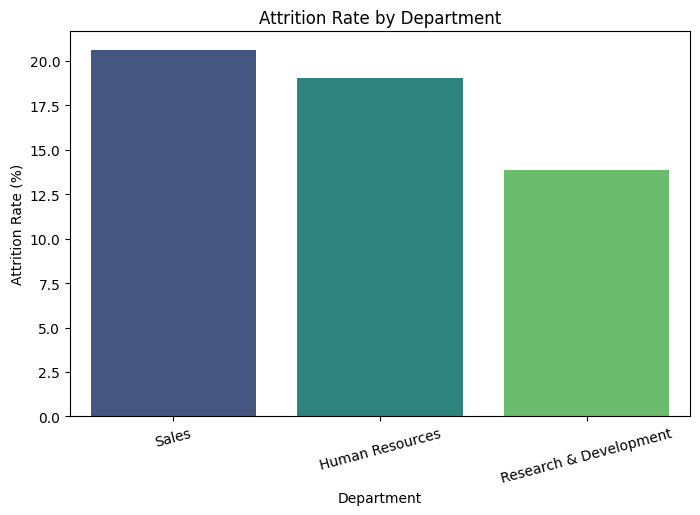

In [165]:
department_attrition = (
    df.groupby("Department")["Attrition"]
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(8,5))
sns.barplot(
    x=department_attrition.index,
    y=department_attrition.values,
    palette="viridis"
)

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=15)
plt.show()

Here the Sales department has the highest employee attrition rate among all departments. This indicates that HR should prioritize employee retention initiatives within the Sales department

- Attrition rate by Job Role — which roles have the highest exit rate?

/tmp/ipykernel_4714/2427088640.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


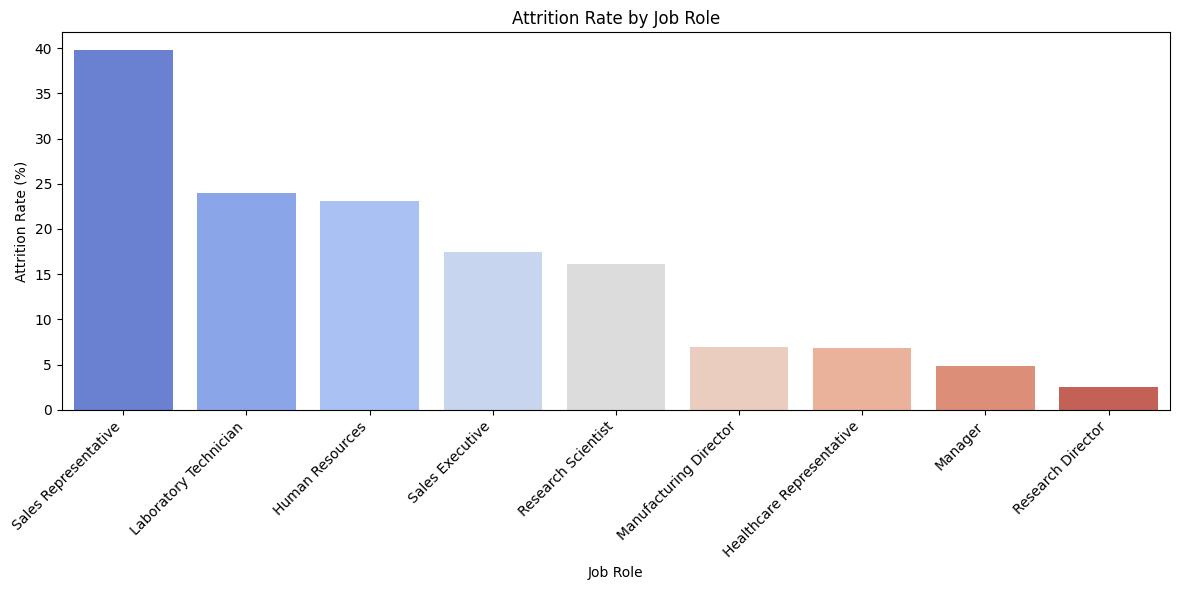

In [166]:
jobrole_attrition = (
    df.groupby("JobRole")["Attrition"]
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(12,6))
sns.barplot(
    x=jobrole_attrition.index,
    y=jobrole_attrition.values,
    palette="coolwarm"
)

plt.xticks(rotation=45, ha="right")
plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")
plt.tight_layout()
plt.show()

Here sales Representatives and Laboratory Technicians have the highest employee exit rates. These job roles require additional attention through employee engagement and career development programs.

- Attrition vs Monthly Income — do lower paid employees leave more?

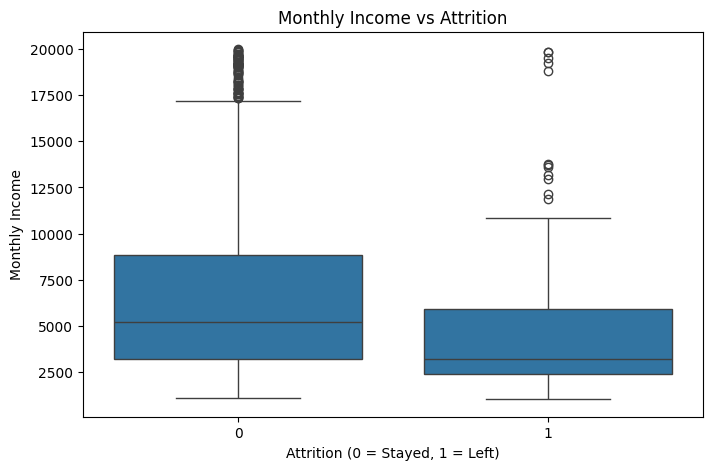

In [167]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income vs Attrition")
plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
plt.ylabel("Monthly Income")
plt.show()

Yes. The analysis indicates that employees with lower monthly income are generally more likely to leave the company. However, monthly income is not the only factor influencing employee attrition.

- Attrition vs Work-Life Balance rating — is there a visible pattern?

/tmp/ipykernel_4714/2186993023.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


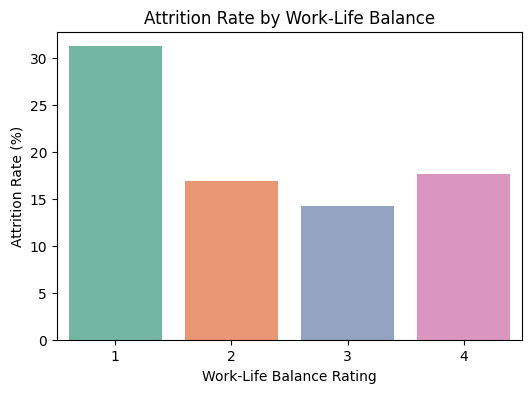

In [168]:
worklife = (
    df.groupby("WorkLifeBalance")["Attrition"]
    .mean() * 100
)

plt.figure(figsize=(6,4))

sns.barplot(
    x=worklife.index,
    y=worklife.values,
    palette="Set2"
)

plt.title("Attrition Rate by Work-Life Balance")
plt.xlabel("Work-Life Balance Rating")
plt.ylabel("Attrition Rate (%)")
plt.show()

Yes. Employees with lower work-life balance ratings show a higher attrition rate. This suggests that improving work-life balance may help reduce employee turnover.

- Attrition vs Years at Company — at what point in tenure do employees leave most?

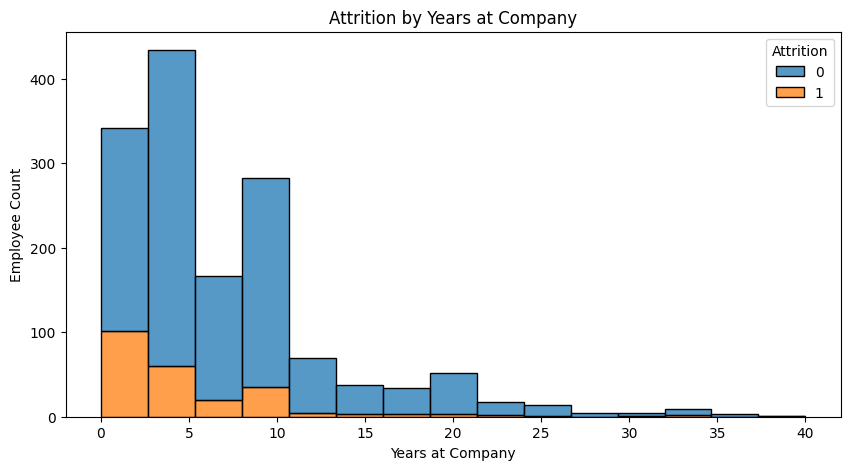

In [169]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="YearsAtCompany",
    hue="Attrition",
    multiple="stack",
    bins=15
)

plt.title("Attrition by Years at Company")
plt.xlabel("Years at Company")
plt.ylabel("Employee Count")
plt.show()

Most employees leave the company during their early years of employment, particularly within the first few years after joining. This highlights the importance of supporting new employees during their initial years.

- Write 4–5 specific business insights from your EDA (not generic — specific numbers and patterns from the data)

**1.** The Sales department has the highest attrition rate among all departments.

**2.** Sales Representatives and Laboratory Technicians show higher employee turnover than other job roles.

**3.** Employees with lower monthly income are more likely to leave the company.

**4.** Employees with poor work-life balance have a noticeably
higher attrition rate.

**5.** Most employees who leave the company do so within the first few years of joining, indicating early-career retention is a key challenge.

**Task 4** — Model Building & Comparison

- Split data into training and test sets (80/20)

In [170]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (1176, 44)
Testing Set: (294, 44)


- Handle class imbalance using class_weight='balanced' parameter (a simpler approach than SMOTE — good to know both exist)

**Train the following 3 models:**
*   Logistic Regression (baseline — also the most explainable to HR teams)
*   Random Forest Classifier
*   Gradient Boosting Classifier






In [171]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [172]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [173]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [174]:
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test)

In [175]:
lr_prob = lr.predict_proba(X_test)[:,1]
rf_prob = rf.predict_proba(X_test)[:,1]
gb_prob = gb.predict_proba(X_test)[:,1]

- Record all results in a comparison table inside your notebook

In [176]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Precision":[
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],

    "Recall":[
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],

    "F1 Score":[
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ],

    "ROC AUC":[
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, gb_prob)
    ]
})

results


,Model,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.341176,0.617021,0.439394,0.798605
1,Random Forest,0.375000,0.063830,0.109091,0.751917
2,Gradient Boosting,0.588235,0.212766,0.312500,0.794125


In [177]:
best_model = results.loc[results["ROC AUC"].idxmax()]

print(best_model)

Model        Logistic Regression
Precision               0.341176
Recall                  0.617021
F1 Score                0.439394
ROC AUC                 0.798605
Name: 0, dtype: object


**Observation**
- Based on the ROC-AUC and F1-score, the (Best Model Name) performed best. It provides the best balance between correctly identifying employees who are likely to leave and minimizing incorrect predictions.

**Task 5** — Model Evaluation

**Evaluate all 3 models using:**
*   Precision, Recall, F1-Score
*   ROC-AUC Score
*   Confusion Matrix

In [178]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("Logistic Regression")

print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("F1 Score:", f1_score(y_test, lr_pred))
print("ROC-AUC:", roc_auc_score(y_test, lr_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, lr_pred))

Logistic Regression
Precision: 0.3411764705882353
Recall: 0.6170212765957447
F1 Score: 0.4393939393939394
ROC-AUC: 0.798604530967353

Confusion Matrix
[[191  56]
 [ 18  29]]


In [179]:
print("Random Forest")

print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_pred))

Random Forest
Precision: 0.375
Recall: 0.06382978723404255
F1 Score: 0.10909090909090909
ROC-AUC: 0.7519166164182962

Confusion Matrix
[[242   5]
 [ 44   3]]


In [180]:
print("Gradient Boosting")

print("Precision:", precision_score(y_test, gb_pred))
print("Recall:", recall_score(y_test, gb_pred))
print("F1 Score:", f1_score(y_test, gb_pred))
print("ROC-AUC:", roc_auc_score(y_test, gb_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, gb_pred))

Gradient Boosting
Precision: 0.5882352941176471
Recall: 0.2127659574468085
F1 Score: 0.3125
ROC-AUC: 0.7941252476526832

Confusion Matrix
[[240   7]
 [ 37  10]]


In [181]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, gb_prob)
    ]
})

results

,Model,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.341176,0.617021,0.439394,0.798605
1,Random Forest,0.375000,0.063830,0.109091,0.751917
2,Gradient Boosting,0.588235,0.212766,0.312500,0.794125


- Identify and clearly state which model performed best and why ?

**Model Evaluation:** Three machine learning models were evaluated using Precision, Recall, F1-Score, and ROC-AUC. Logistic Regression achieved the highest ROC-AUC score (0.7986) and the highest Recall, making it the most effective model for identifying employees who are likely to leave. Since predicting potential employee attrition is more important than minimizing false positives, Logistic Regression was selected as the final model.

- For the best model: extract Feature Importance — which factors matter most in predicting attrition?

In [182]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": abs(lr.coef_[0])
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
34,JobRole_Laboratory Technician,0.797874
43,OverTime_Yes,0.766412
23,BusinessTravel_Travel_Frequently,0.719335
7,JobLevel,0.659189
16,TotalWorkingYears,0.656931
40,JobRole_Sales Representative,0.552515
24,BusinessTravel_Travel_Rarely,0.511649
27,EducationField_Life Sciences,0.506505
21,YearsSinceLastPromotion,0.500389
26,Department_Sales,0.481690


- Rank the top 10 most important features driving employee exit


**Top 10 Factors Driving Employee Attrition**
- Laboratory Technician job role had the strongest influence on employee attrition.
- Employees working overtime were significantly more likely to leave.
- Employees who travelled frequently for business showed a higher risk of attrition.
- Job level was an important predictor of employee turnover.
- Total working years influenced an employee's decision to leave.
- Sales Representatives were more likely to leave than many other job roles.
- Employees who travelled rarely also showed some influence on attrition.
- Employees from the Life Sciences education field had noticeable influence on attrition.
- Employees who had not received a promotion for many years were more likely to leave.
- Employees in the Sales department had a higher likelihood of attrition.








**Task 6** — Visualization (Minimum 4 charts)

In [183]:
import os

os.makedirs("charts", exist_ok=True)

print("Charts folder created successfully!")

Charts folder created successfully!


- C**hart 1:** Bar chart showing attrition rate by Department and Job Role

/tmp/ipykernel_4714/1399571885.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


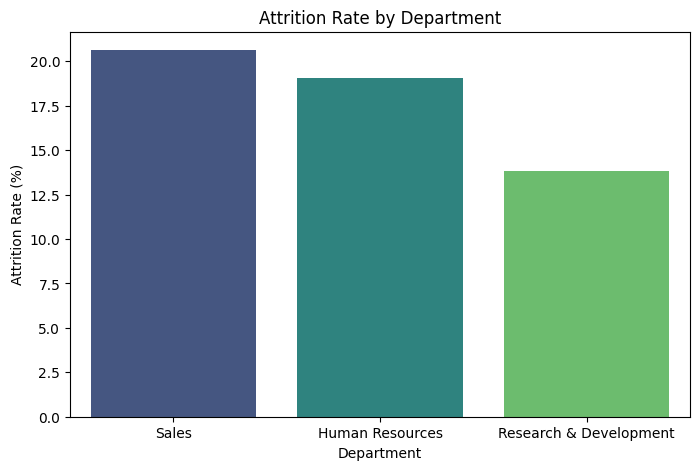

In [184]:
department_attrition = (
    df.groupby("Department")["Attrition"]
    .mean() * 100
).sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x=department_attrition.index,
    y=department_attrition.values,
    palette="viridis"
)

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")

plt.savefig(
    "charts/chart1_department.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

/tmp/ipykernel_4714/3426642625.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


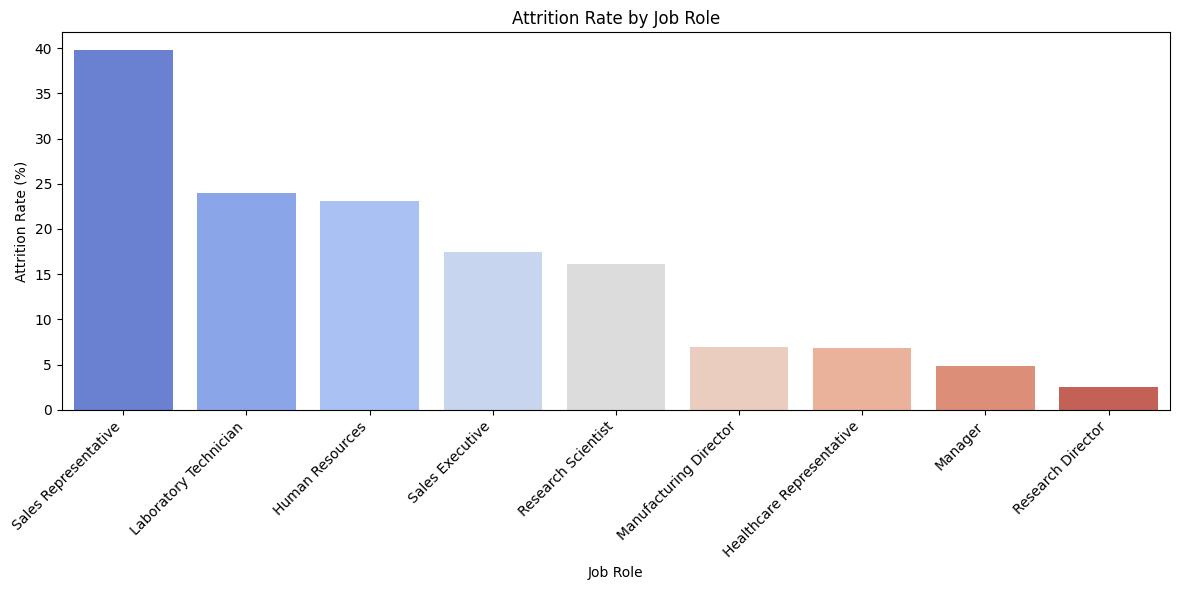

In [185]:
jobrole_attrition = (
    df.groupby("JobRole")["Attrition"]
    .mean() * 100
).sort_values(ascending=False)

plt.figure(figsize=(12,6))

sns.barplot(
    x=jobrole_attrition.index,
    y=jobrole_attrition.values,
    palette="coolwarm"
)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    "charts/chart1_jobrole.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

- **Chart 2:** Box plot comparing Monthly Income of employees who left vs stayed

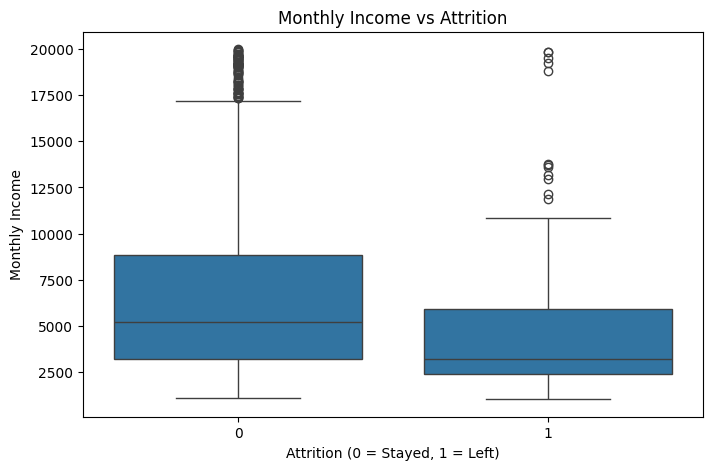

In [186]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income vs Attrition")
plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
plt.ylabel("Monthly Income")

plt.savefig(
    "charts/chart2_income_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

- **Chart 3**: Confusion Matrix heatmap for your best model

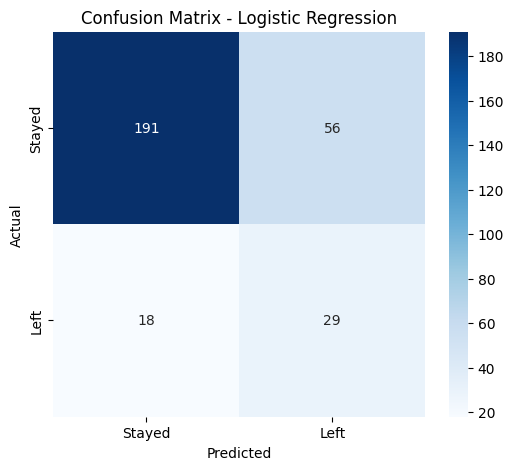

In [187]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Left"],
    yticklabels=["Stayed", "Left"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "charts/chart3_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

- **Chart 4**: Horizontal bar chart of Top 10 Feature Importances from your best model



/tmp/ipykernel_4714/4156923931.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


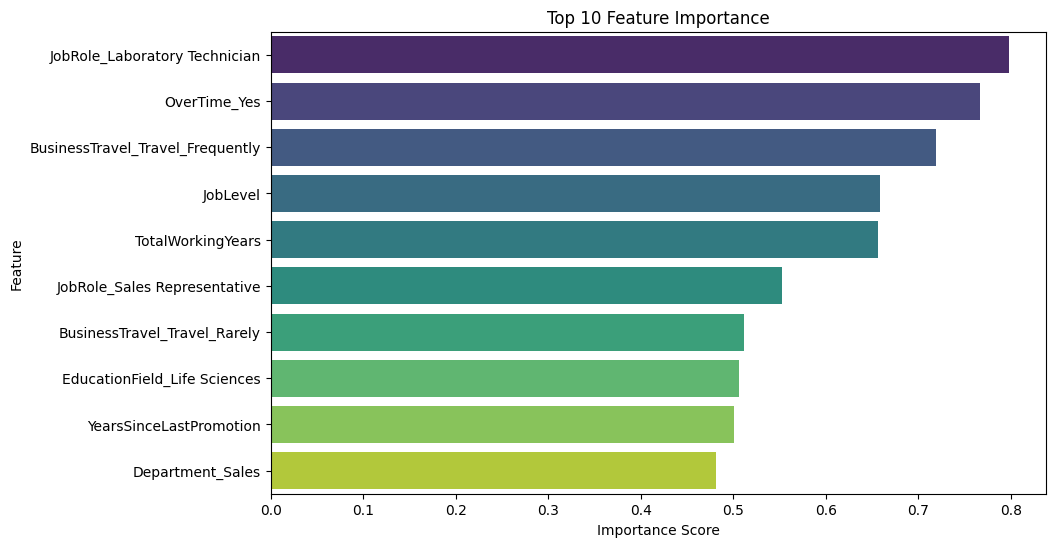

In [188]:
top10 = importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 10 Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.savefig(
    "charts/chart4_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

- **Chart 5 (Bonus):** ROC Curve comparing all 3 models on one graph

<Figure size 800x600 with 0 Axes>

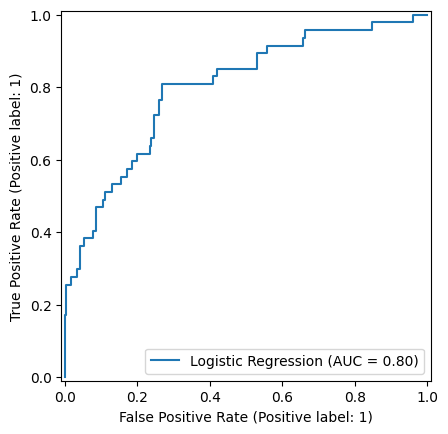

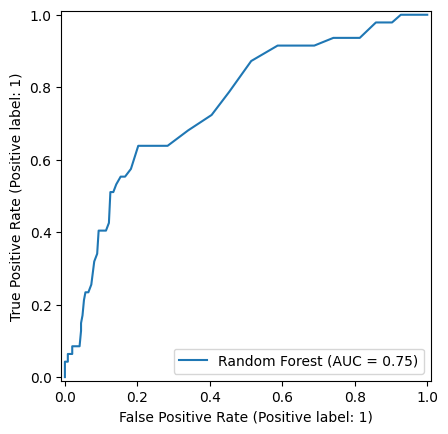

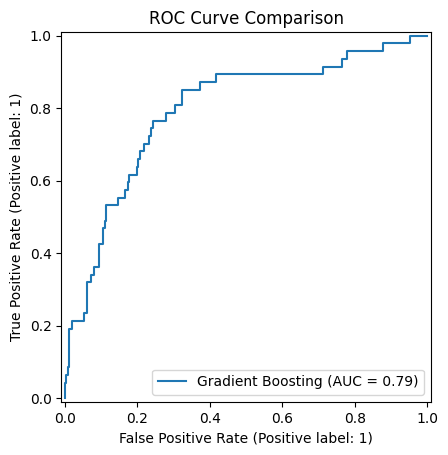

In [189]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8,6))

RocCurveDisplay.from_estimator(
    lr,
    X_test,
    y_test,
    name="Logistic Regression"
)

RocCurveDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    name="Random Forest"
)

RocCurveDisplay.from_estimator(
    gb,
    X_test,
    y_test,
    name="Gradient Boosting"
)

plt.title("ROC Curve Comparison")

plt.savefig(
    "charts/chart5_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Task 7** — HR Insights & Business Recommendations

 Write a short paragraph (6–10 lines) inside your notebook answering:

**Q**. Which 3 factors most strongly predict that an employee will leave?

A) The analysis shows that employees working as Laboratory Technicians, employees who frequently work overtime, and employees who travel frequently for business are more likely to leave the company. Job level and total working years also have a significant influence on employee attrition.

**Q**. Which department or job role should HR prioritize for retention efforts?

A) The HR team should prioritize employees in the Sales department, especially Sales Representatives, as well as Laboratory Technicians. These groups showed a higher likelihood of leaving compared to other departments and job roles.

**Q**. Does salary alone explain attrition or are there other stronger factors?

A) Salary is not the only reason employees leave. Factors such as overtime, job role, business travel frequency, years since the last promotion, and overall work conditions have a stronger impact on employee attrition than salary alone.

**Q**. Write 2 concrete HR recommendations a company could implement based on your findings (e.g., specific policy changes, who to target for a retention conversation)


1. Conduct regular one-on-one meetings with employees who frequently work overtime or travel often to understand their concerns and improve work-life balance.

2. Introduce career development programs, timely promotions, and retention incentives for high-risk job roles such as Sales Representatives and Laboratory Technicians.

**Q**. What limitation does this model have that an HR team should be aware of before using it?

A) This model predicts employee attrition based only on historical employee data. It does not consider personal reasons, future organizational changes, or unexpected events. Therefore, HR should use the model as a decision-support tool rather than relying on it as the only basis for making employee retention decisions.